In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
import pytorch_lightning as pl
from torch.utils.data import Dataset, Subset, DataLoader

from hierroute.constants import *
from hierroute.extra_functions import set_seed
from hierroute.data_setup import ImageDataset, HierImageDataset
from hierroute.hierarchy import Hierarchy
from hierroute import Trainer, HierRouteNet

/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
set_seed(SEED)

DataPath = '/Users/alexandermichaeltjhin/Everything/Repos/Zooplankton/data/WHOI-Plankton'
DataSubdirectory = [
    '2006','2007','2008','2009','2010','2011', '2012',
    '2013','2014']
adj_graph = whoi_adjacency_graph_s
RESOLUTION = 65

SELECTED_LIST = [key for key, item in adj_graph.items() if len(item) == 0]

dataset = ImageDataset(
    data_directory = '/Users/alexandermichaeltjhin/Everything/Repos/Zooplankton/data/WHOI-Plankton',
    data_subdirectories = DataSubdirectory,
    class_names = SELECTED_LIST,
    max_class_size = 6000,
    image_resolution = 64,
    image_transforms = None,
    format_file = '.png',
    seed = SEED
    )

whoi_dataset = HierImageDataset(
    base_dataset=dataset,
    adjacency_graph = adj_graph,
    levels=3,
    leaves_only=True
)
whoi_dataset.print_dataset_details()

[leaves_only] Kept 46844 samples | Removed 0 non-leaf samples

Total Dataset: Size = 46844 | Levels = 3
all_node_counts: {0: 46844, 1: 34339, 3: 8148, 7: 6000, 8: 295, 9: 1853, 4: 26191, 10: 0, 11: 6000, 12: 2191, 13: 6000, 14: 0, 15: 6000, 16: 0, 17: 6000, 2: 12505, 5: 5161, 18: 0, 19: 5161, 6: 7344, 20: 6000, 21: 711, 22: 633}

nodes_by_level: {0: [0], 1: [1, 2], 2: [3, 4, 5, 6], 3: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]}


------------------------Level 0------------------------
Level: 0 | Class Name: root                 | Class Label:   0 | Type: Parent | Count:  46844 | Prop: 1.00

------------------------Level 1------------------------
Level: 1 | Class Name: Colonial             | Class Label:   1 | Type: Parent | Count:  34339 | Prop: 0.73
Level: 1 | Class Name: Unicellular          | Class Label:   2 | Type: Parent | Count:  12505 | Prop: 0.27

------------------------Level 2------------------------
Level: 2 | Class Name: C-Spines             | Class Labe

In [4]:
from torch.utils.data import Dataset, Subset, DataLoader, SequentialSampler, WeightedRandomSampler, random_split
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.Pad(padding = 5, fill = 0),
    transforms.Resize((RESOLUTION, RESOLUTION)),
    transforms.ToTensor(),
])


whoi_dataset.append_image_transforms(
    image_transforms = train_transforms, replace = True
)

TRAIN_PROP = 0.7
VAL_PROP = 0.1
TEST_PROP = 0.2

BATCH_SIZE = 64

train_split, val_split, test_split = whoi_dataset.split_train_test_val(
    train_prop = TRAIN_PROP, val_prop = VAL_PROP, test_prop = TEST_PROP
)

# Create dataloaders
train_loader, val_loader, test_loader = whoi_dataset.create_dataloaders(
    batch_size = BATCH_SIZE,
    train_indices = train_split,
    val_indices = val_split,
    test_indices = test_split,
    image_transforms = None,
    train_sample_weights = None,
    balanced=True
)


In [5]:
import time
from datetime import date



today = date.today()

if torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f'Using device: MPS (Apple Silicon GPU)')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using device: CUDA GPU')
else:
    device = torch.device('cpu')
    print(f'Using device: CPU')
# backbone = "swin_t"
backbone = "efficientnet_b0"
expert_type="cnn"
model = HierRouteNet(whoi_dataset.hierarchy, whoi_dataset.label_to_ids,
                #    loss_type = "focal", 
                   backbone= backbone, 
                   freeze_backbone=False,
                   expert_type=expert_type)
HYPERPARAMETERS = {
    'lr': 3e-4, 
    'epochs': 40, 
    'scheduler':False,
    'early_stopping': {'patience': 5, 'delta': 0.001},
}
start = time.time()
trainer = Trainer(learning_rate=HYPERPARAMETERS['lr'], max_epochs=HYPERPARAMETERS['epochs'], device=device,
                  print_every=1, model_dir=f"{backbone}_whoi_{expert_type}_{today}")
trainer.fit(model, train_loader, val_loader, scheduler=HYPERPARAMETERS['scheduler'],
            patience=HYPERPARAMETERS['early_stopping']['patience'],
            delta=HYPERPARAMETERS['early_stopping']['delta'])
print(f"Total time taken {round((time.time() - start) / 60, 2)} minutes")

Using device: MPS (Apple Silicon GPU)
Training at device: mps
Directory 'efficientnet_b0_whoi_cnn_2026-03-24' already exists — saving to 'efficientnet_b0_whoi_cnn_2026-03-24_5' instead.
beginning training
Epoch [1/40] | Train Loss: 0.1426 | Train Acc: 0.4547 | Train F1: 0.4096 | Valid Loss: 0.1266 | Valid Acc: 0.5172 | Valid F1: 0.5088 | Saved best model (val_acc=0.5172)
Epoch [2/40] | Train Loss: 0.1086 | Train Acc: 0.6098 | Train F1: 0.5994 | Valid Loss: 0.1246 | Valid Acc: 0.5283 | Valid F1: 0.5085 | Saved best model (val_acc=0.5283)
Epoch [3/40] | Train Loss: 0.1000 | Train Acc: 0.6441 | Train F1: 0.6372 | Valid Loss: 0.1163 | Valid Acc: 0.5940 | Valid F1: 0.5787 | Saved best model (val_acc=0.5940)
Epoch [4/40] | Train Loss: 0.0927 | Train Acc: 0.6799 | Train F1: 0.6772 | Valid Loss: 0.1099 | Valid Acc: 0.6171 | Valid F1: 0.5895 | Saved best model (val_acc=0.6171)
Epoch [5/40] | Train Loss: 0.0872 | Train Acc: 0.6998 | Train F1: 0.6966 | Valid Loss: 0.0990 | Valid Acc: 0.6572 | Val

In [6]:
# saved_dir = "efficient_net_whoi_2026-03-11_2"
print(f"loading from {trainer.model_dir}")
model = HierRouteNet(whoi_dataset.hierarchy, whoi_dataset.label_to_ids, checkpoint_dir=trainer.model_dir,
                   backbone= backbone, expert_type=expert_type)
result = trainer.predict(model, test_loader, save=True)

loading from efficientnet_b0_whoi_cnn_2026-03-24_5
Loaded checkpoint: efficientnet_b0_whoi_cnn_2026-03-24_5/best_model.pt
Hierarchical Evaluation:
  Level 1: Acc=0.9636 | F1=0.9531 | Prec=0.9573 | Rec=0.9491 | n=9369
    Colonial               Acc=0.9802 | F1=0.9753 | Prec=0.9704 | Rec=0.9802 | n=6868
    Unicellular            Acc=0.9180 | F1=0.9309 | Prec=0.9441 | Rec=0.9180 | n=2501
  Level 2: Acc=0.9276 | F1=0.9171 | Prec=0.9231 | Rec=0.9114 | n=9369
    C-Spines               Acc=0.8656 | F1=0.8656 | Prec=0.8656 | Rec=0.8656 | n=1630
    C-NoSpines             Acc=0.9527 | F1=0.9464 | Prec=0.9403 | Rec=0.9527 | n=5238
    U-Spines               Acc=0.9021 | F1=0.9264 | Prec=0.9519 | Rec=0.9021 | n=1032
    U-NoSpines             Acc=0.9251 | F1=0.9299 | Prec=0.9347 | Rec=0.9251 | n=1469
  Level 3: Acc=0.8602 | F1=0.8427 | Prec=0.8261 | Rec=0.8660 | n=9369
    Chaetoceros            Acc=0.7967 | F1=0.8438 | Prec=0.8968 | Rec=0.7967 | n=1200
    Lauderia               Acc=0.6780 | F

In [12]:
from hierroute import Visualize

Saved → training_result/mnr/swin_t_cnn/train_metrics.png


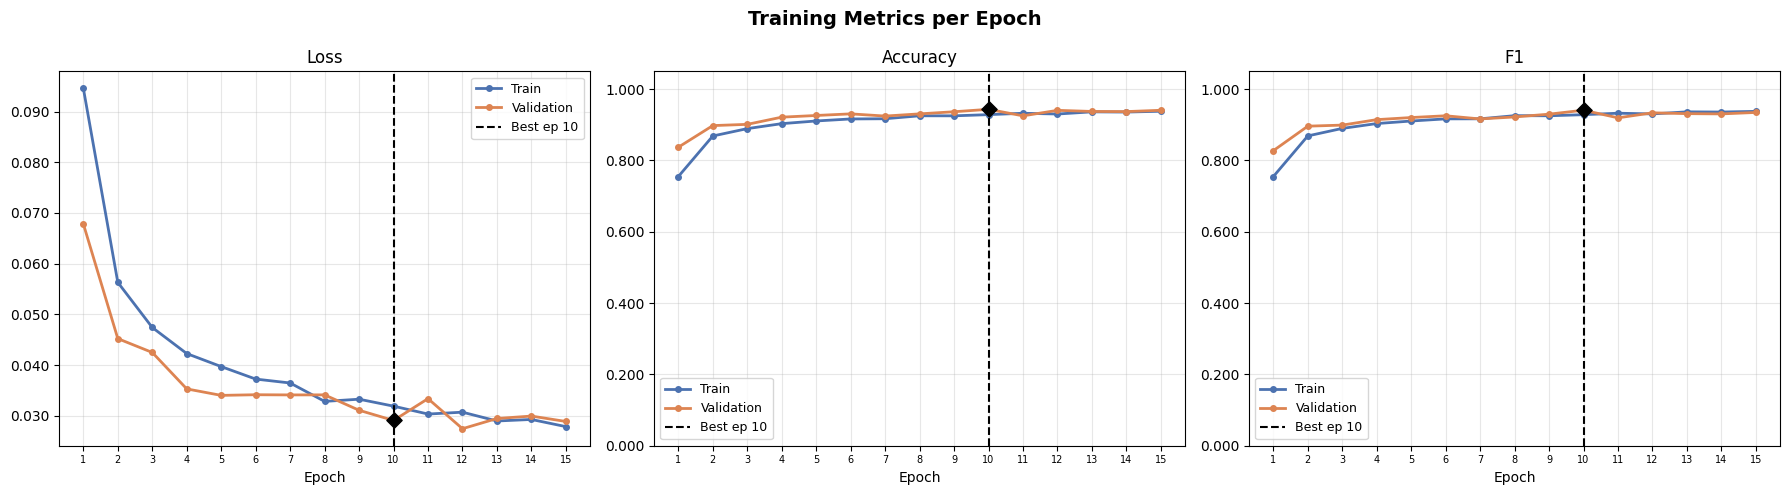

In [29]:
# path = trainer.model_dir
path = "training_result/mnr/swin_t_cnn"
vis = Visualize(path)
vis.plot_train()

Saved → training_result/mnr/swin_t_cnn/confusion_matrix_level1.png


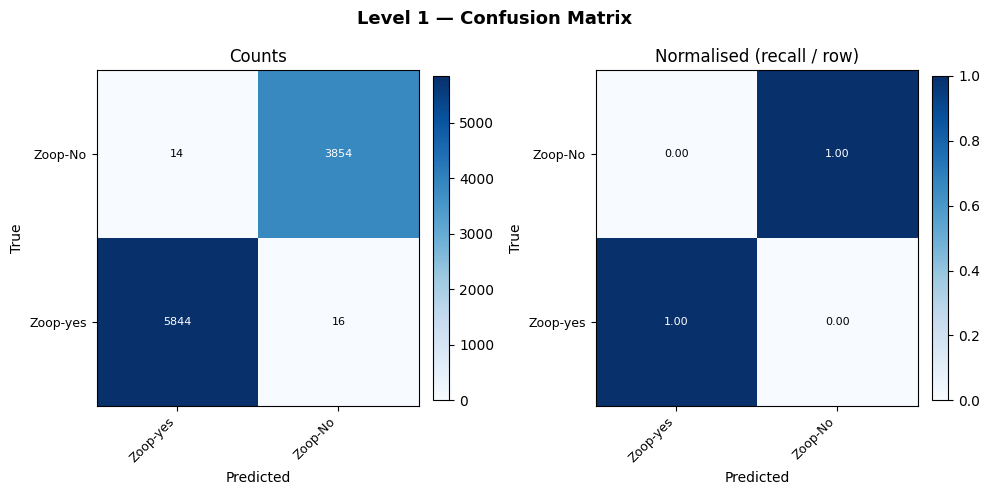

Saved → training_result/mnr/swin_t_cnn/class_metrics_level1.png


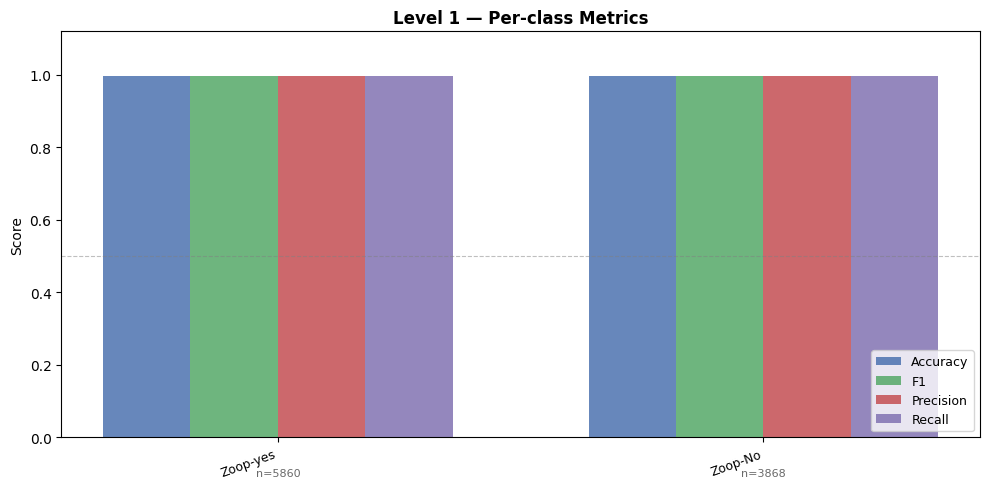

Saved → training_result/mnr/swin_t_cnn/confusion_matrix_level2.png


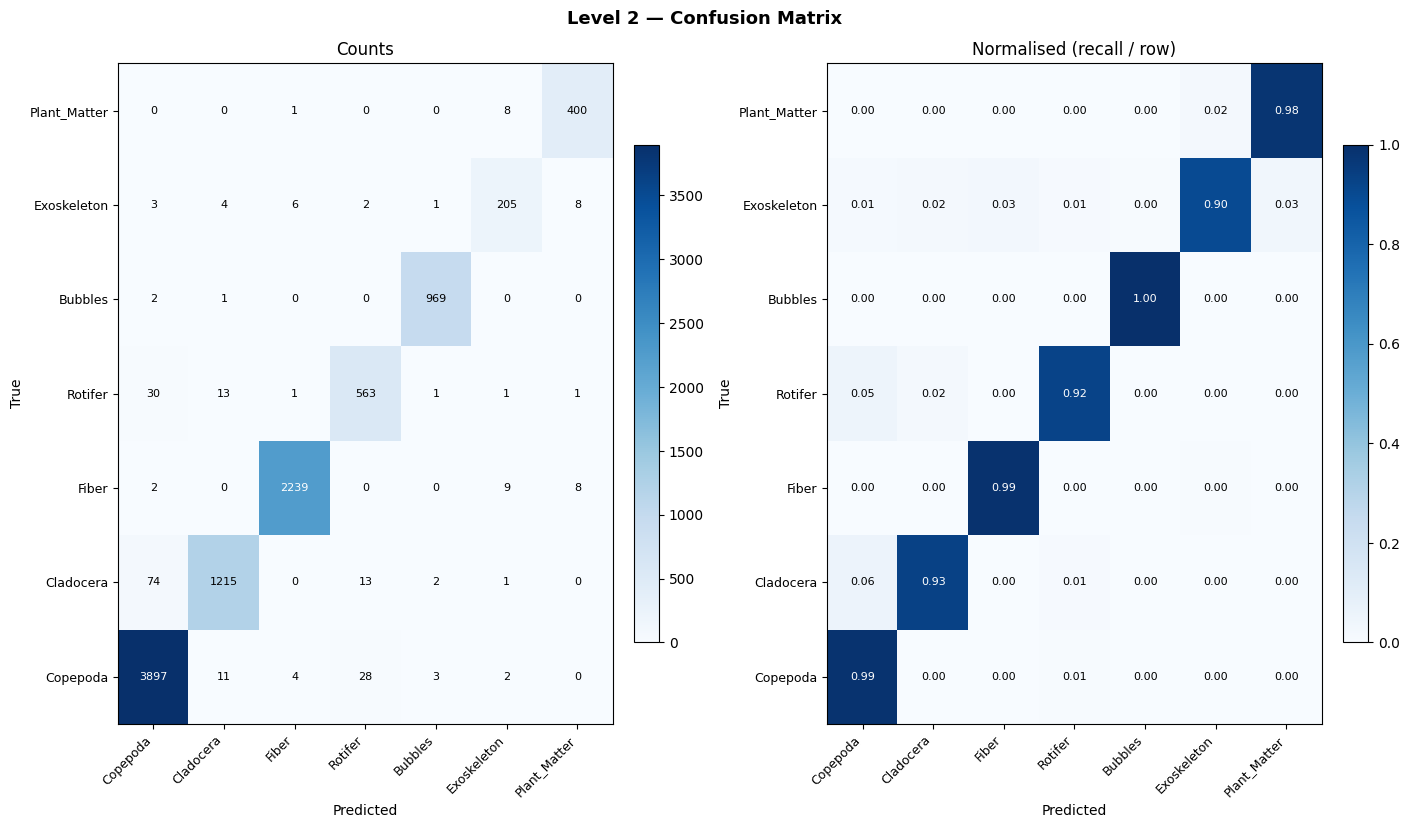

Saved → training_result/mnr/swin_t_cnn/class_metrics_level2.png


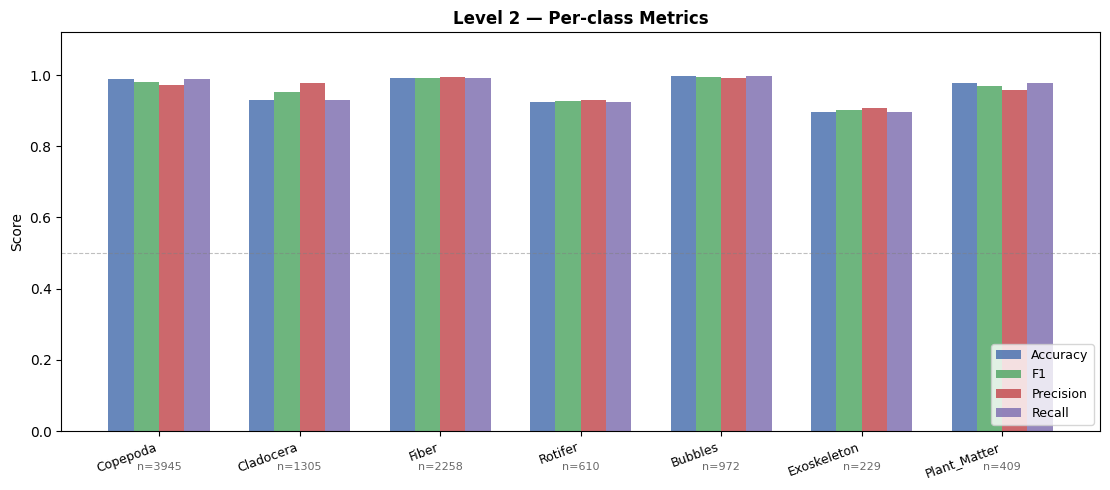

Saved → training_result/mnr/swin_t_cnn/confusion_matrix_level3.png


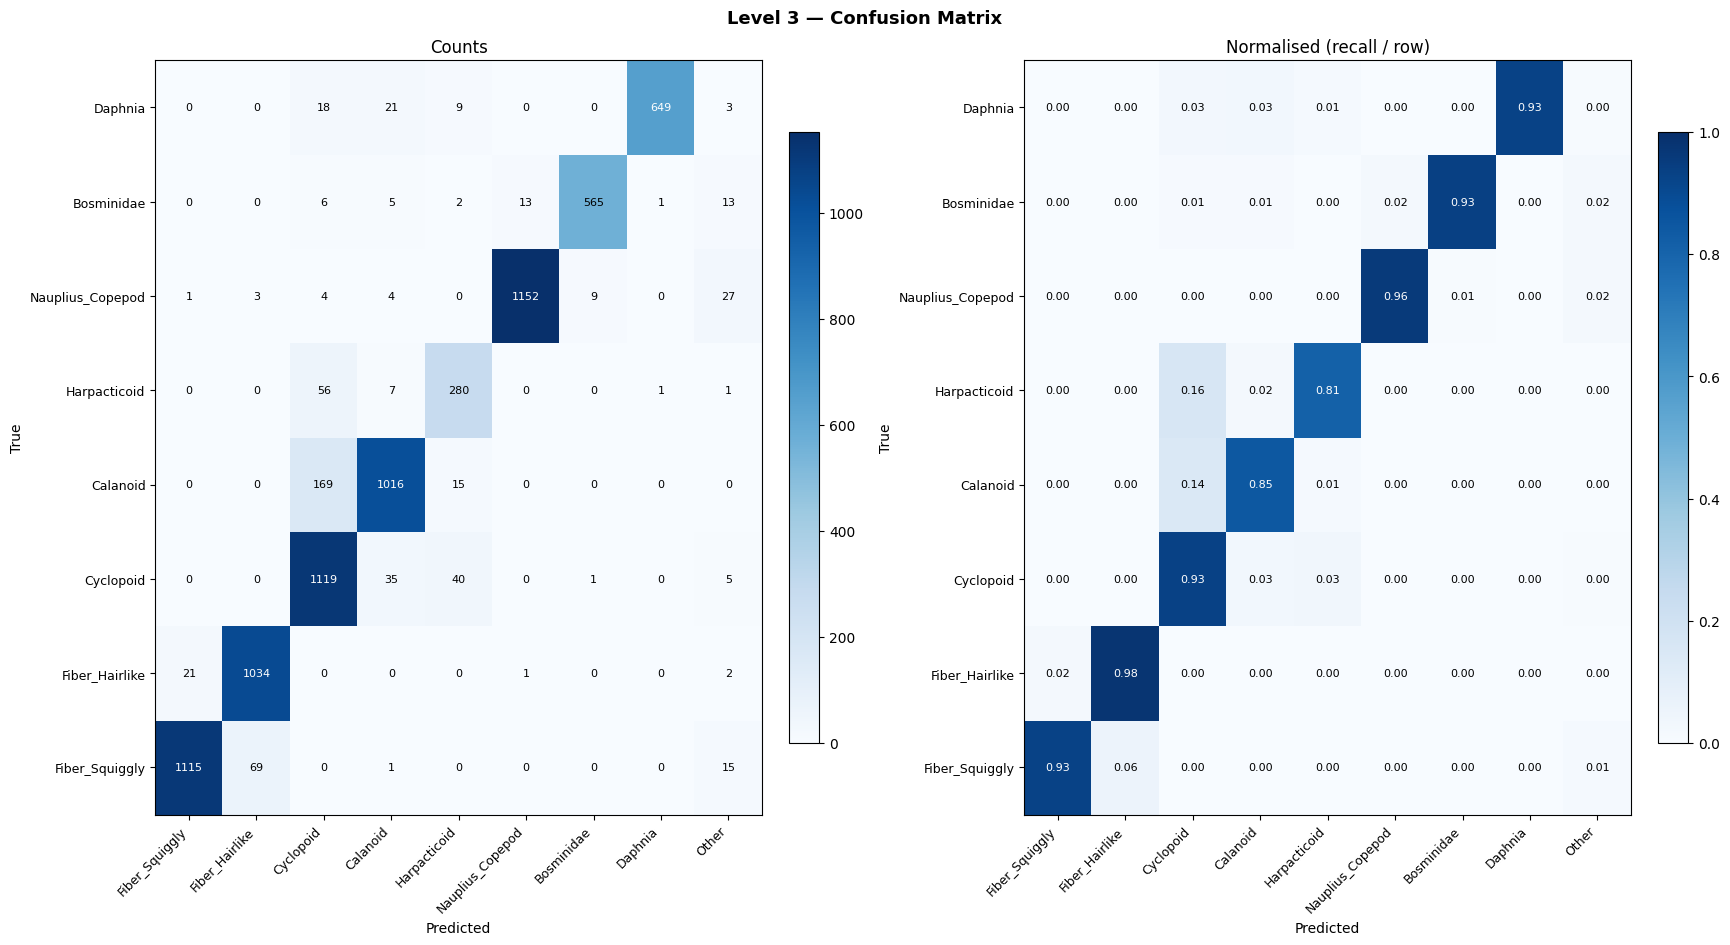

Saved → training_result/mnr/swin_t_cnn/class_metrics_level3.png


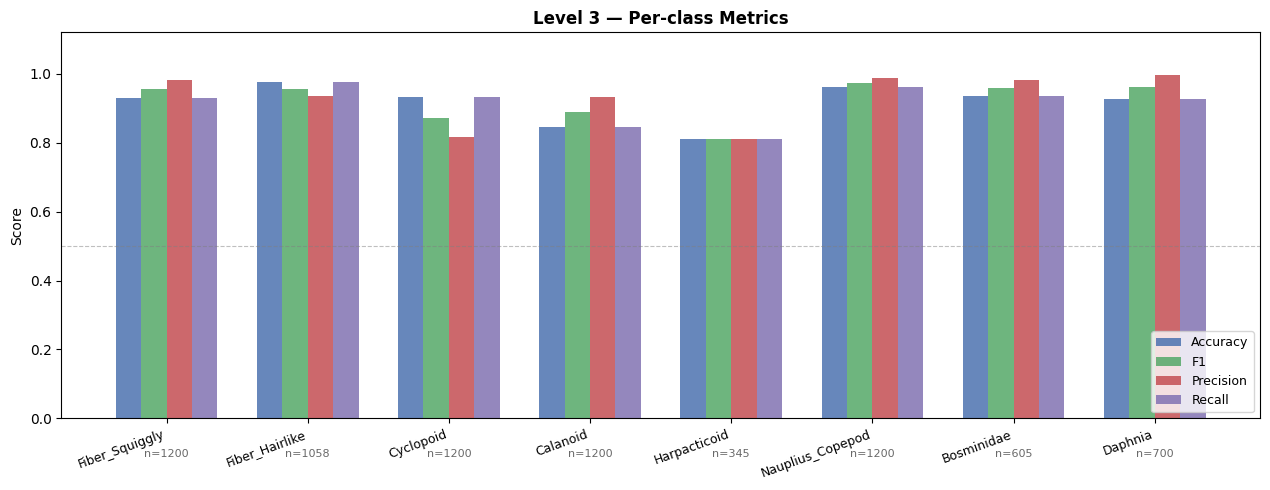

Saved → training_result/mnr/swin_t_cnn/level_comparison.png


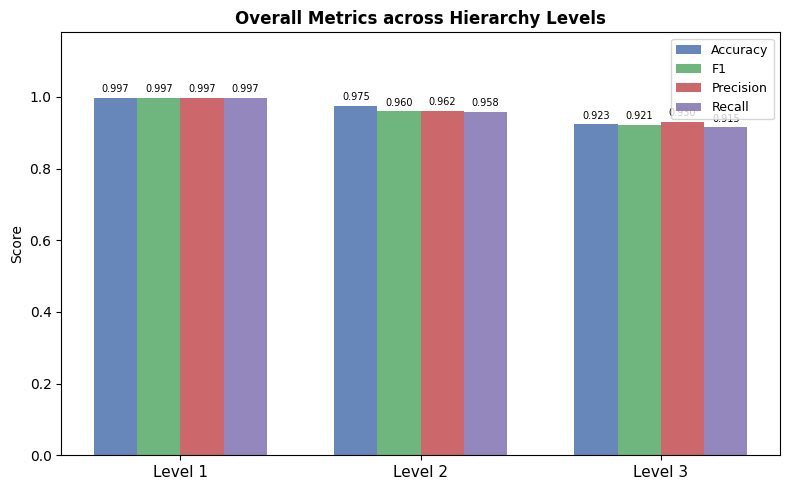

In [30]:
vis.plot_pred()

Saved → training_result/mnr/swin_t_cnn/level_comparison.png


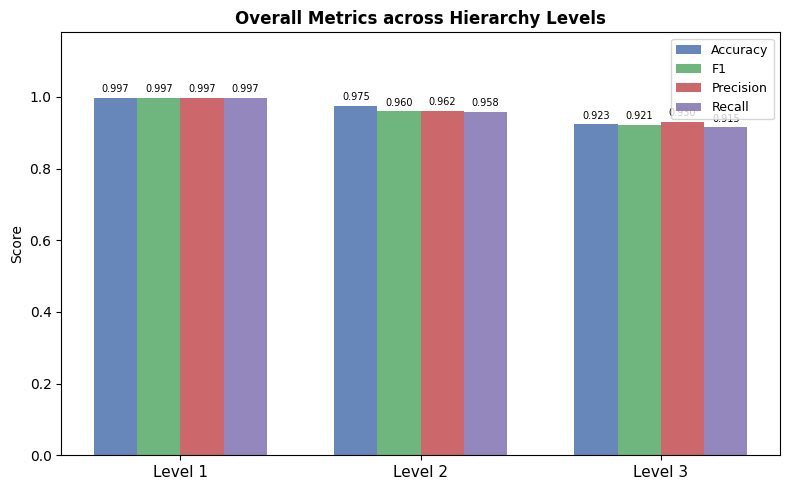

In [31]:
vis.plot_level_comparison()

Saved → training_result/mnr/swin_t_cnn/size_vs_accuracy.png


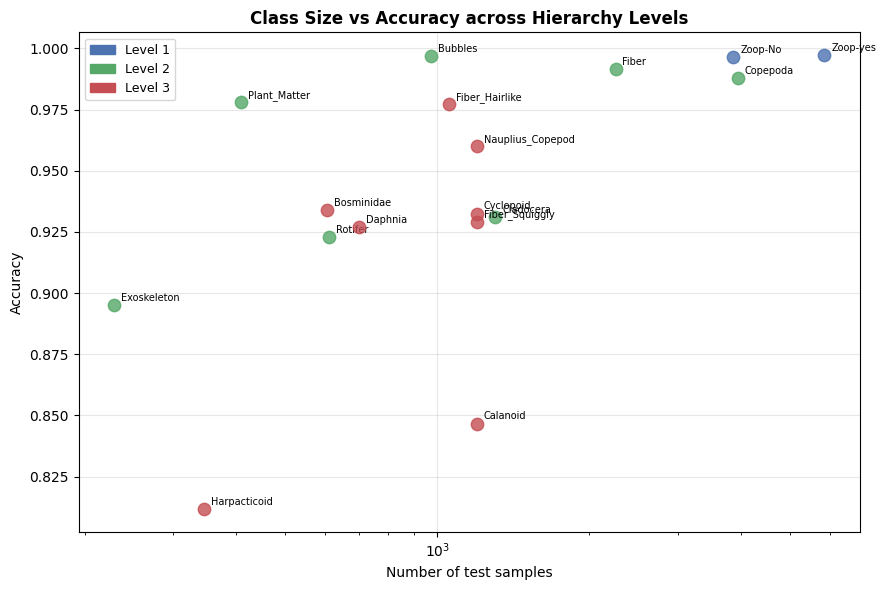

In [32]:
vis.plot_class_size_vs_accuracy()